<a href="https://colab.research.google.com/github/dan-the-man7/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


In [ ]:
## x and y variables created and used to plot sin wave graph

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0,0.1,size=x.shape)

plt.scatter(x, y, s=10)
plt.title("Noisy sine data")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

## Initiasing w and b
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

## Finding gradient descent

learning_rate = 0.05
losses = []

for step in range(200):

  # Calculates the model's current prediction
  y_h = w * x + b

  # Calculates the current loss
  loss = np.mean((y_h - y) ** 2)

  # Calculates gradients (derivatives of w and b)

  dw = np.mean(2 * (y_h - y) * x)
  db = np.mean(2 * (y_h - y))

  # This is the update rule. It moves w and b a small step opposite the gradient
  w -= learning_rate * dw
  b -= learning_rate * db


  # Stores the loss value in the losses array, to use later for plotting a loss graph

  losses.append(loss)

  print(f"Final value for w ={w:.3f}, b= {b:.3f}, loss = {losses[-1]:.4f}")

  fig, axes = plt.subplots(1,2, figsize=(12,4))

  # Plots loss curve to flatten out
  axes[0].plot(losses)
  axes[0].set_title("Loss over training steps")
  axes[0].set_xlabel("step")
  axes[0].set_ylabel("MSE loss")


  axes[1].scatter(x,y, s=10, label="data")
  axes[1].plot(x, w * x + b, color="red", label="fitted line")
  axes[1].set_title("Fit: single neuron vs. sine data")
  axes[1].legend()

  plt.tight_layout()
  plt.show()





## Student Reasoning for Part 1.1
2. The model is overfitting, this is because it is too simple to capture the true structure, therefore the training loss rises to a high value and stays high despite the training time.

A single neuron never fits a sine wave because, the function y_hat = w*x + b is the graph of a straight line, and will never fit a sine wave, no matter how long you train. This is because a sine wave, never bevomes becomes a line at any point except locally or instantaneously.



## Student Reflection 1.2

1. Without tanh, h = z1 = x @ W1 + b1. Because W1W2 and W2 + b2 are fixed numbers, they are of the form y_hat = wx + b, no matter how many hidden neurons are used. Stacking layers without a non-linearity between them, is mathematically identical to one linear layer.

2. Each hidden neuron applies tanh to its own linear transformation of x, so each one produces its own S-shaped curved, which is shifted and scaled differently. The output layer takes a weighted combination of these 8 bent curves.

3. Backward propagation refers to the process of working backward from the loss through each layer of the network, to compute how every parameter contributed to the final error value.

## Student Reflection 1.3

1. The blue line represents a slow stable learning. This means that the model slowly descends towards the minimum loss, but it takes about 1000 steps to reach a loss of 10^0.

  The orange line represents efficient learning rate. This means that it takes a relatively lesser time to reach 10^0. It does it about 10 times faster than the blue line.

  The green line represents an exploding gradient, this means that on the first step, the error increases rapidly and goes off the chart.

2. A high learning rate means that the step taken towards the bottom of the gradient. Instead of taking little steps, a massive step is taken causing it to go completely across the valley and land on the opposite wall.

/tmp/ipykernel_1310/165586089.py:25: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_h - y_col) ** 2)
/tmp/ipykernel_1310/165586089.py:32: RuntimeWarning: overflow encountered in matmul
  dh = d_yh @ W2.T
/tmp/ipykernel_1310/165586089.py:33: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


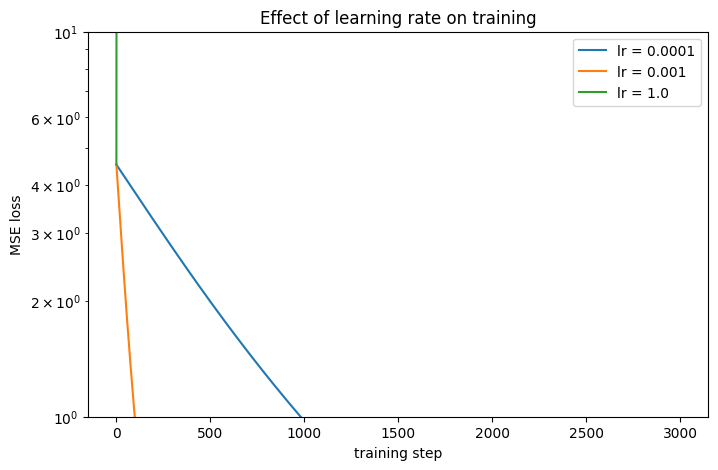

In [22]:

#Part 1.3
def train_toy(learning_rate, steps = 3000):
# Resets the seed every time the function is called
# guaranteeing that all three runs begin from the exact same random initial weights.
# Therefore, any differences seen afterwards are caused by only the learning rate.
    np.random.seed(RANDOM_STATE)

    W1 = np.random.randn(1,8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8,1) * 0.5
    b2 = np.random.randn(1) * 0.5

    x_col = x.reshape(-1, 1)
    y_col = y.reshape(-1, 1)

    losses = []

    for step in range(steps):
      # Forward pass
      z1 = x_col @ W1 + b1
      # Applies tanh
      h = np.tanh(z1)
      y_h = h @ W2 + b2

      ## Mean Squared Error
      loss = np.mean((y_h - y_col) ** 2)

      # Backward Pass

      d_yh = 2 * (y_h - y_col) / len(y_col)
      dW2 = h.T @ d_yh
      dB2 = d_yh.sum(axis = 0)
      dh = d_yh @ W2.T
      dz1 = dh * (1 - np.tanh(z1) ** 2)
      dW1 = x_col.T @ dz1
      db1 = dz1.sum(axis=0)

      # Update, adjust every parameter a small step opposite its gradient.
      W1 -= learning_rate * dW1
      b1 -= learning_rate * db1
      W2 -= learning_rate * dW2
      b2 -= learning_rate * dB2

      losses.append(loss)

    return losses

# print(f"Final Loss Value is {losses[-1]:.4f}")

learning_rates = [0.0001, 0.001, 1.0]
results = {}

for lr in learning_rates:
  results[lr] = train_toy(lr, steps=3000)

fig, ax = plt.subplots(figsize=(8, 5))

for lr, losses in results.items():
  ax.plot(losses, label=f"lr = {lr}")

ax.set_yscale("log")
ax.set_xlabel("training step")
ax.set_ylabel("MSE loss")
ax.set_title("Effect of learning rate on training")
ax.legend()
plt.show()
